## 1. Импорты и общие настройки

In [1]:
# Базовые библиотеки для воспроизводимости, анализа и удобного отображения результатов.
import random
from typing import Iterable
from datasets import load_dataset
import matplotlib.pyplot as plt
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import confusion_matrix
import seaborn as sns

import numpy as np
import pandas as pd
import torch

from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    Trainer,
    pipeline,
    TrainingArguments,
    DataCollatorWithPadding
)

In [2]:
# Фиксируем seed и определяем устройство.
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pipeline_device = 0 if torch.cuda.is_available() else -1
print(f"Device: {device}")

Device: cpu


## Данные

Размеры: {'train': 16000, 'validation': 2000, 'test': 2000}
Классы: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}
Пример из train:
Текст: i feel like i have to make the suffering i m seeing mean something
Эмоция: sadness (метка: 0)
--------------------------------------------------

Пример из validation:
Текст: i feel like i am still looking at a blank canvas blank pieces of paper
Эмоция: sadness (метка: 0)
--------------------------------------------------

Пример из test:
Текст: im feeling rather rotten so im not very ambitious right now
Эмоция: sadness (метка: 0)
--------------------------------------------------


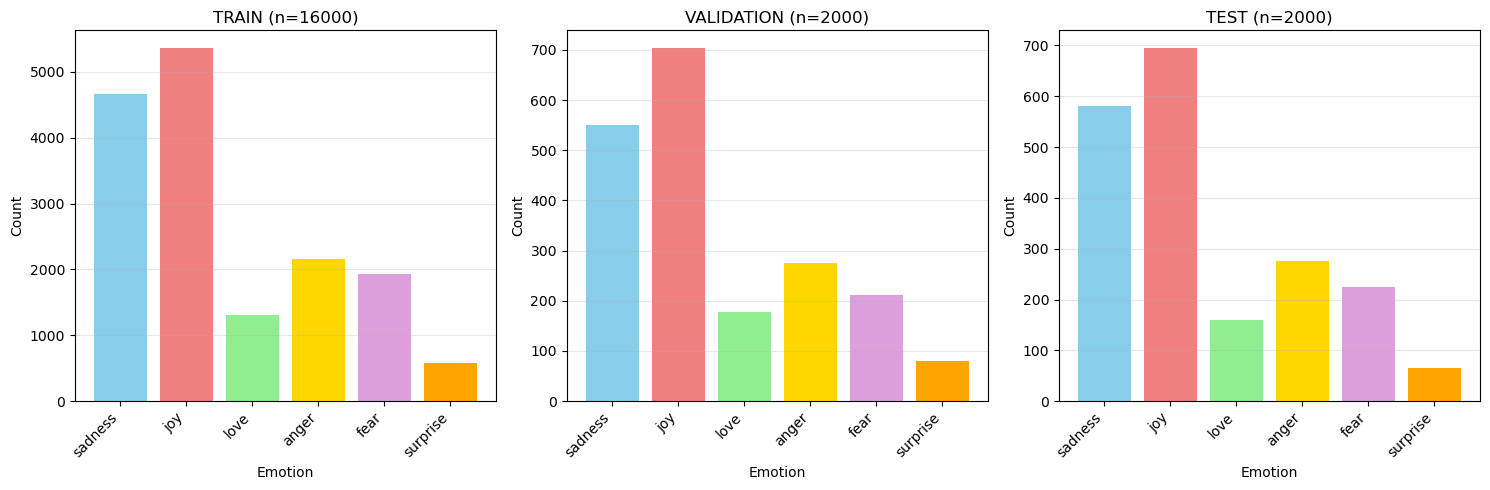

In [4]:
# Загрузка датасета
dataset = load_dataset("emotion")
emotion_labels = {
    0: "sadness",
    1: "joy", 
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}

def sanity_check():

    print("Размеры:", {k: len(v) for k, v in dataset.items()})
    print("Классы:", emotion_labels)

    # Функция для отображения примеров с названиями эмоций
    def show_example(dataset_split, idx):
        example = dataset_split[idx]
        text = example['text']
        label_id = example['label']
        emotion_name = emotion_labels[label_id]
        print(f"Текст: {text}")
        print(f"Эмоция: {emotion_name} (метка: {label_id})")
        print("-" * 50)

    # Показываем примеры из разных сплитов
    print("Пример из train:")
    show_example(dataset["train"], random.randint(0,10))

    print("\nПример из validation:")
    show_example(dataset["validation"], random.randint(0,10))

    print("\nПример из test:")
    show_example(dataset["test"], random.randint(0,10))

    _, axes = plt.subplots(1, 3, figsize=(15, 5))

    for idx, split in enumerate(["train", "validation", "test"]):
        labels = dataset[split]["label"]
        counts = [labels.count(i) for i in range(6)]
        
        axes[idx].bar(range(6), counts, color=['skyblue', 'lightcoral', 'lightgreen', 'gold', 'plum', 'orange'])
        axes[idx].set_title(f"{split.upper()} (n={len(labels)})")
        axes[idx].set_xlabel("Emotion")
        axes[idx].set_ylabel("Count")
        axes[idx].set_xticks(range(6))
        axes[idx].set_xticklabels([emotion_labels[i] for i in range(6)], rotation=45, ha='right')
        axes[idx].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

sanity_check()

Задача - классифицировать эмоциональную окраску сообщения по исходному тексту (sadness, joy, love, anger, fear, surprise)

## Токенизация

In [5]:
MODEL_NAME = "bhadresh-savani/bert-base-uncased-emotion"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded:", MODEL_NAME)
print("Tokenizer class:", tokenizer.__class__.__name__)
print("Model max length:", tokenizer.model_max_length)

Tokenizer loaded: bhadresh-savani/bert-base-uncased-emotion
Tokenizer class: BertTokenizer
Model max length: 512


In [6]:
# Берем 5 текстов из train
texts = [dataset["train"][i]["text"] for i in range(5)]
print("Исходные тексты:\n")
for i, t in enumerate(texts):
    print(f"{i+1}. {t}")

Исходные тексты:

1. i didnt feel humiliated
2. i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
3. im grabbing a minute to post i feel greedy wrong
4. i am ever feeling nostalgic about the fireplace i will know that it is still on the property
5. i am feeling grouchy


In [7]:
# Токенизация с padding и truncation
tokens = tokenizer(
    texts,
    padding="max_length",
    truncation=True,
    max_length=20,
    return_tensors="pt"
)

print(f"Форма батча: {tokens['input_ids'].shape}")
# Показываем для каждого текста
for i in range(len(texts)):
    print(f"\n--- ТЕКСТ {i+1} ---")
    print(f"Оригинал: {texts[i]}")
    
    # Токены (слова)
    input_ids = tokens["input_ids"][i]
    decoded_tokens = tokenizer.convert_ids_to_tokens(input_ids)
    print(f"\nТокены: {decoded_tokens}")
    
    # input_ids
    print(f"input_ids: {input_ids.tolist()}")
    
    # attention_mask
    print(f"attention_mask: {tokens['attention_mask'][i].tolist()}")
    
    # Special tokens
    print(f"Special tokens: [CLS]={tokenizer.cls_token_id}, [SEP]={tokenizer.sep_token_id}, [PAD]={tokenizer.pad_token_id}")
    print(f"  [CLS] в начале: {decoded_tokens[0]}")
    print(f"  [SEP] в конце: {decoded_tokens[input_ids.tolist().index(tokenizer.sep_token_id)]}")
    
    # Padding (показываем если есть)
    if tokenizer.pad_token_id in input_ids:
        pad_positions = (input_ids == tokenizer.pad_token_id).nonzero(as_tuple=True)[0]
        print(f"Это пример Padding: {len(pad_positions)} токенов [PAD] в конце")
    
    # Truncation (показываем если был)
    original_len = len(tokenizer.encode(texts[i], add_special_tokens=False))
    if original_len > 20:
        print(f"Это пример Truncation: было {original_len}, стало 20 токенов (обрезано)")

Форма батча: torch.Size([5, 20])

--- ТЕКСТ 1 ---
Оригинал: i didnt feel humiliated

Токены: ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
input_ids: [101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Special tokens: [CLS]=101, [SEP]=102, [PAD]=0
  [CLS] в начале: [CLS]
  [SEP] в конце: [SEP]
Это пример Padding: 13 токенов [PAD] в конце

--- ТЕКСТ 2 ---
Оригинал: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake

Токены: ['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', '[SEP]']
input_ids: [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105,

## Инференс готовой модели

In [8]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device)
model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bhadresh-savani/bert-base-uncased-emotion
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [9]:
# Создаём high-level pipeline для классификации текста.
inference_pipeline = pipeline(
    task="text-classification",
    model=model,
    tokenizer=tokenizer,
    device=pipeline_device,
)

demo_texts = [dataset["validation"][i]["text"] for i in range(10, 15)]
pipeline_outputs = inference_pipeline(demo_texts)

pipeline_df = pd.DataFrame(
    {
        "text": demo_texts,
        "true_label": [emotion_labels[dataset["validation"][i]["label"]] for i in range(10, 15)],
        "predicted_label": [item["label"] for item in pipeline_outputs],
        "confidence": [item["score"] for item in pipeline_outputs],
    }
)

pipeline_df

,text,true_label,predicted_label,confidence
0,i feel bitchy but not defeated yet,anger,anger,0.998000
1,i was dribbling on mums coffee table looking o...,joy,joy,0.999093
2,i woke up often got up around am feeling pukey...,sadness,joy,0.994305
3,i was feeling sentimental,sadness,sadness,0.998373
4,i walked out of there an hour and fifteen minu...,sadness,sadness,0.998466


In [10]:
def evaluate(pipe, dataset, set_="validation"):
    texts = list(dataset[set_]["text"])
    true = dataset[set_]["label"]
    
    preds = pipe(texts)
    
    # Определяем формат меток
    first_label = preds[0]["label"]
    if first_label.startswith("LABEL_"):
        pred_ids = [int(pred["label"].split("_")[-1]) for pred in preds]
    else:
        # Для модели emotion (возвращает 'sadness', 'joy' и т.д.)
        emotion_to_id = {
            "sadness": 0, "joy": 1, "love": 2,
            "anger": 3, "fear": 4, "surprise": 5
        }
        pred_ids = [emotion_to_id[pred["label"]] for pred in preds]
    
    acc = accuracy_score(true, pred_ids)
    f1 = f1_score(true, pred_ids, average="macro")
    
    print(f"Accuracy: {acc:.3f}")
    print(f"F1 Macro: {f1:.3f}")
    
    return acc, f1

In [11]:
evaluate(inference_pipeline, dataset, set_="validation")

Accuracy: 0.941
F1 Macro: 0.920


(0.9405, 0.9198101107862923)

Модель пригодна для использования, если:
- Допустима погрешность ~10-15%
- Нужно различать базовые эмоции (anger/joy/sadness)
- Не подходит для критических задач (суицидальные тексты, медицинская диагностика)
- Не подходит, если важна высокая точность на смешанных/амбивалентных эмоциях

## Эксперименты - Fine-tuning

In [12]:
MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=len(emotion_labels))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [13]:
def tokenize(x):
    return tokenizer(x["text"], padding=False, truncation=True, max_length=128)

tokenized = dataset.map(tokenize, batched=True)
tokenized = tokenized.rename_column("label", "labels")
tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

In [14]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")

    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
    }

In [15]:
# Data collator будет добавлять padding динамически, прямо при формировании батча.
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

sample_batch = [tokenized["train"][i] for i in range(3)]
collated_batch = data_collator(sample_batch)

for key, value in collated_batch.items():
    print(f"{key}: shape={tuple(value.shape)}")

labels: shape=(3,)
input_ids: shape=(3, 23)
attention_mask: shape=(3, 23)


In [16]:
# Общие параметры обучения.
common_training_kwargs = dict(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16, 
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,  
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
    dataloader_num_workers=2, # параллельная загрузка данных
)
try:
    training_args = TrainingArguments(
        evaluation_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )
except:
    training_args = TrainingArguments(
        eval_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )

training_args

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=2,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=Fals

In [ ]:
# Собираем Trainer и запускаем обучение.
# В transformers >= 5.0 аргумент tokenizer переименован в processing_class.
try:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
except TypeError:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

train_result = trainer.train()
train_result

/home/ian/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.207543,0.211510,0.932000,0.907976
2,0.135150,0.164651,0.936000,0.907741
3,0.085856,0.160969,0.942000,0.918796


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/home/ian/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/home/ian/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=3000, training_loss=0.23471808528900145, metrics={'train_runtime': 3101.9601, 'train_samples_per_second': 15.474, 'train_steps_per_second': 0.967, 'total_flos': 1161463243423104.0, 'train_loss': 0.23471808528900145, 'epoch': 3.0})

In [17]:
finetune_pipeline = pipeline(
    "text-classification",
    model="./results/checkpoint-3000",
    tokenizer=tokenizer,
    device="cpu"
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [18]:
evaluate(finetune_pipeline, dataset, "validation")

Accuracy: 0.942
F1 Macro: 0.919


(0.942, 0.9187963778958835)

In [19]:
evaluate(finetune_pipeline, dataset, "test")

Accuracy: 0.929
F1 Macro: 0.879


(0.929, 0.8785747484718479)

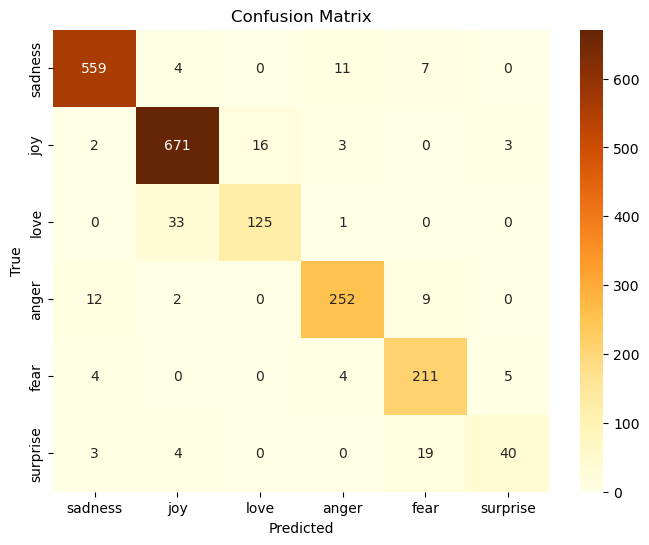

True: fear     | Pred: anger    | Score: 0.670 | i don t feel particularly agitated...
True: sadness  | Pred: sadness  | Score: 0.999 | i feel beautifully emotional knowing that these wo...
True: fear     | Pred: fear     | Score: 0.930 | i pay attention it deepens into a feeling of being...
True: joy      | Pred: joy      | Score: 0.999 | i just feel extremely comfortable with the group o...
True: love     | Pred: love     | Score: 0.994 | i find myself in the odd position of feeling suppo...
True: sadness  | Pred: sadness  | Score: 0.999 | i was feeling as heartbroken as im sure katniss wa...
True: joy      | Pred: joy      | Score: 0.999 | i feel a little mellow today...
True: sadness  | Pred: sadness  | Score: 0.999 | i feel like my only role now would be to tear your...
True: anger    | Pred: anger    | Score: 0.998 | i feel just bcoz a fight we get mad to each other ...
True: joy      | Pred: joy      | Score: 0.999 | i feel like reds and purples are just so rich and ...


In [23]:
# Предсказания
test_texts = list(dataset["test"]["text"])
test_true = dataset["test"]["label"]

test_preds = finetune_pipeline(test_texts)
test_pred_ids = [int(pred["label"].split("_")[-1]) for pred in test_preds]
test_scores = [pred["score"] for pred in test_preds]

emotions = ["sadness", "joy", "love", "anger", "fear", "surprise"]
cm = confusion_matrix(test_true, test_pred_ids)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=emotions, yticklabels=emotions, cmap='YlOrBr')
plt.title("Confusion Matrix")
plt.ylabel("True")
plt.xlabel("Predicted")    
plt.savefig('artifacts/confusion_matrix.png', dpi=150)
plt.show()

# 10 примеров предсказаний
for i in range(10, 20):
    text = dataset["test"][i]["text"]
    true_e = emotions[test_true[i]]
    pred_e = emotions[test_pred_ids[i]]
    score = test_scores[i]
    print(f"True: {true_e:8} | Pred: {pred_e:8} | Score: {score:.3f} | {text[:50]}...")

Модель иногда путает `love` и `joy`, `anger` и `sadness` а также между `fear` и `surprise`, что нельзя отнести к грубым ошибкам. Как правило, неверные предсказания модели соответствуют маленькому значению confidence, ошибки могут быть связаны с тем , что исходный текст содержит маркеры разных классов в схождей пропорции.

In [21]:
demo_texts = [dataset["test"][i]["text"] for i in range(10, 15)]
demo_true = [dataset["test"][i]["label"] for i in range(10, 15)]

# Получаем предсказания с confidence
demo_preds = finetune_pipeline(demo_texts)

# Создаем DataFrame
sample_predictions = pd.DataFrame(
    {
        "text": demo_texts,
        "true_label": [emotion_labels[l] for l in demo_true],
        "predicted_label": [pred["label"] for pred in demo_preds],
        "confidence": [pred["score"] for pred in demo_preds],
    }
)

sample_predictions.to_csv("artifacts/sample_predictions.csv", index=False)